# EBA 3650  Carbon Tax Revenue Recycling
**Group 6 | Puskar Acharya, Peien Chen, Qianqian Cui**

**Research Question:** Which revenue recycling mechanism — universal lump-sum redistribution or targeted compensation — more effectively mitigates the regressive effects of carbon taxation, and what is the associated efficiency cost in terms of aggregate labour supply?

---

- **Lump-sum**: equal transfer to every household
- **Targeted**: larger transfers to lower-income households

Sections:
1. Imports & Parameters
2. Household Setup
3. Utility Function & Household Solver
4. Firm Side & GE Solver
5. Labour-Supply Graph
6. Scenario Runs (τ = 0.20)
7. Carbon Tax Burden by Decile
8. Welfare Change by Decile
9. Change in Clean-Good Consumption
10. Equity–Emissions Trade-off
11. Efficiency Cost of Recycling Schemes
12. Labour Market Equilibrium Graph


## 1. Imports & Parameters

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# ------- PARAMETERS -------
N            = 1000
alpha        = 3.0   # leisure preference

gamma_min    = 0.20
gamma_max    = 0.65

tau          = 0.20
lambda_target = 1.75

phi          = 1.0

tol          = 1e-6
max_iter     = 200


## 2. Household Setup

Wages are drawn from a log-normal distribution, then normalised to mean 1.
Each household gets a `gamma` (expenditure share on the dirty good `x`)
that decreases with income rank, with a small noise term added.


In [34]:
wages = np.random.lognormal(0, 0.3, N)
wages = wages / np.mean(wages)

df0 = pd.DataFrame({"w": wages})
df0 = df0.sort_values("w").reset_index(drop=True)
df0["rank"] = np.linspace(0, 1, N)

gamma_base = gamma_max - (gamma_max - gamma_min) * df0["rank"]
noise      = np.random.normal(0, 0.02, N)
df0["gamma"] = np.clip(gamma_base + noise, 0.05, 0.95)

print(df0.describe())


                 w         rank        gamma
count  1000.000000  1000.000000  1000.000000
mean      1.000000     0.500000     0.426417
std       0.306179     0.289109     0.132167
min       0.359946     0.000000     0.153805
25%       0.783725     0.250000     0.314619
50%       0.959033     0.500000     0.426417
75%       1.155996     0.750000     0.535474
max       3.023451     1.000000     0.686100


## 3. Utility Function & Household Solver

Utility:

$$U = \gamma \ln(x) + (1-\gamma) \ln(y) + \alpha \ln(1-l)$$

FOC for labour:

$$\frac{w}{w l + T} = \frac{\alpha}{1-l}
\quad\Longrightarrow\quad
l^* = \frac{w - \alpha T}{w(1+\alpha)}$$

Optimal demands:

$$x = \frac{\gamma m}{p_x}, \qquad y = (1-\gamma)m,
\qquad m = w l^* + T$$


In [35]:
def utility(l, w, T, gamma, p_x):
    if l <= 0 or l >= 1:
        return -1e12
    m = w * l + T
    if m <= 0:
        return -1e12
    x = gamma * m / p_x
    y = (1 - gamma) * m
    if x <= 0 or y <= 0:
        return -1e12
    return (
        gamma * np.log(x)
        + (1 - gamma) * np.log(y)
        + alpha * np.log(1 - l)
    )


def solve_households(df, T_array, w_eq, p_x):
    l_list, x_list, y_list = [], [], []
    for i in range(len(df)):
        w_i   = w_eq * df.loc[i, "w"]
        gamma  = df.loc[i, "gamma"]
        T      = T_array[i]

        l_star = (w_i - alpha * T) / (w_i * (1 + alpha))
        l_star = np.clip(l_star, 1e-6, 0.95)

        m = w_i * l_star + T
        if m <= 1e-12:
            m = 1e-12

        x = gamma * m / p_x
        y = (1 - gamma) * m

        l_list.append(l_star)
        x_list.append(x)
        y_list.append(y)

    df_out      = df.copy()
    df_out["l"] = l_list
    df_out["x"] = x_list
    df_out["y"] = y_list
    return df_out


## 4. Firm Side & General Equilibrium Solver

Labour demand:

$$L^d(w) = \frac{0.8}{w + 0.5}$$

The GE solver iterates until the labour market clears and transfers converge.


In [36]:
def labor_demand(w):
    return 0.8 / (w + 0.5)


def solve_GE(df, scheme, tau_val):
    p_x     = 1 + tau_val
    T_array = np.zeros(len(df))
    w_eq    = 1.0

    for _ in range(max_iter):
        df_hh    = solve_households(df, T_array, w_eq, p_x)
        L_supply = df_hh["l"].mean()
        L_demand = labor_demand(w_eq)

        excess = L_supply - L_demand
        w_new  = max(0.05, w_eq - 0.2 * excess)

        X = df_hh["x"].sum()
        R = tau_val * phi * X

        if scheme == "lump":
            T_new = np.ones(len(df)) * (R / len(df))

        elif scheme == "target":
            T_bar = R / len(df)
            T_new = T_bar * (1 + lambda_target * (1 - df["rank"]))
            total = T_new.sum()
            if total > 1e-10:
                T_new *= R / total
            else:
                T_new = np.zeros(len(df))

        else:   # "none"
            T_new = np.zeros(len(df))

        if np.abs(w_new - w_eq) < tol and np.max(np.abs(T_new - T_array)) < tol:
            w_eq    = w_new
            T_array = T_new.copy()
            break

        w_eq    = w_new
        T_array = T_new.copy()

    df_hh          = solve_households(df, T_array, w_eq, p_x)
    df_hh["T"]     = T_array
    df_hh.attrs["w_eq"] = w_eq
    return df_hh


# Helper: compute utility for each household after GE
def add_utility(df, tau_used):
    df   = df.copy()
    w_eq = df.attrs["w_eq"]
    p_x  = 1 + tau_used
    U_list = []
    for i in range(len(df)):
        w_i   = w_eq * df.loc[i, "w"]
        l     = df.loc[i, "l"]
        T     = df.loc[i, "T"]
        gamma  = df.loc[i, "gamma"]
        U_list.append(utility(l, w_i, T, gamma, p_x))
    df["U"] = U_list
    return df


# Helper: assign income deciles
def add_deciles(df):
    df = df.copy()
    df["decile"] = pd.qcut(df["w"], 10, labels=False)
    return df


## 5. Labour Supply vs. Net Wage

With T = 0, the closed-form solution gives a constant labour supply
l* = 1/(1+alpha), independent of the wage.


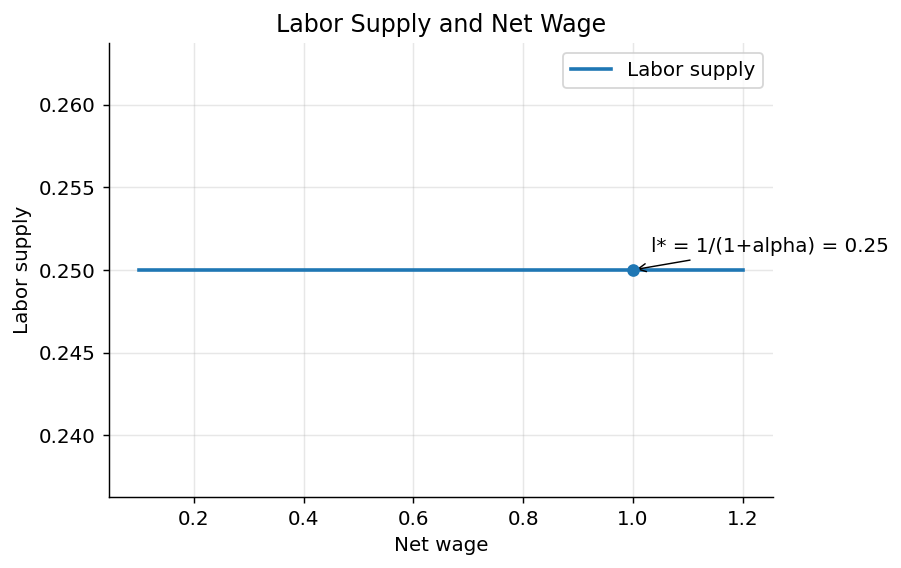

In [37]:
w_net    = np.linspace(0.1, 1.2, 300)
l_supply = np.ones_like(w_net) * (1 / (1 + alpha))

w_net_example = 1.0
l_example     = 1 / (1 + alpha)

plt.figure(figsize=(7, 4.5))
plt.plot(w_net, l_supply, linewidth=2, label="Labor supply")
plt.scatter(w_net_example, l_example, zorder=5)
plt.annotate(
    f"l* = 1/(1+alpha) = {l_example:.2f}",
    (w_net_example, l_example),
    xytext=(10, 10),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=0.8)
)
plt.xlabel("Net wage")
plt.ylabel("Labor supply")
plt.title("Labor Supply and Net Wage")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Scenario Runs (tau = 0.20)

Run four scenarios: no-tax baseline, tax-only (no recycling), lump-sum, targeted.


In [ ]:
# No-tax baseline
df_notax     = solve_GE(df0.copy(), "none", 0.0)
df_notax     = add_utility(df_notax, 0.0)
df_notax     = add_deciles(df_notax)

# Tax-only (no recycling)
df_tax_only  = solve_GE(df0.copy(), "none", tau)
df_tax_only  = add_utility(df_tax_only, tau)
df_tax_only  = add_deciles(df_tax_only)

# Lump-sum recycling
df_lump      = solve_GE(df0.copy(), "lump", tau)
df_lump      = add_utility(df_lump, tau)
df_lump      = add_deciles(df_lump)

# Targeted recycling
df_target    = solve_GE(df0.copy(), "target", tau)
df_target    = add_utility(df_target, tau)
df_target    = add_deciles(df_target)

# Welfare relative to no-tax baseline
df_lump["dU"]   = df_lump["U"]   - df_notax["U"]
df_target["dU"] = df_target["U"] - df_notax["U"]

print("Equilibrium wages:")
print(f"  No-tax  : {df_notax.attrs['w_eq']:.4f}")
print(f"  Tax-only: {df_tax_only.attrs['w_eq']:.4f}")
print(f"  Lump    : {df_lump.attrs['w_eq']:.4f}")
print(f"  Targeted: {df_target.attrs['w_eq']:.4f}")


## 7. Carbon Tax Burden by Decile

Burden is measured as tax paid on the dirty good divided by labour income.


C:\Users\Låneprodukt\AppData\Local\Temp\ipykernel_13836\3791123774.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  burden = df_tax_only.groupby("decile").apply(


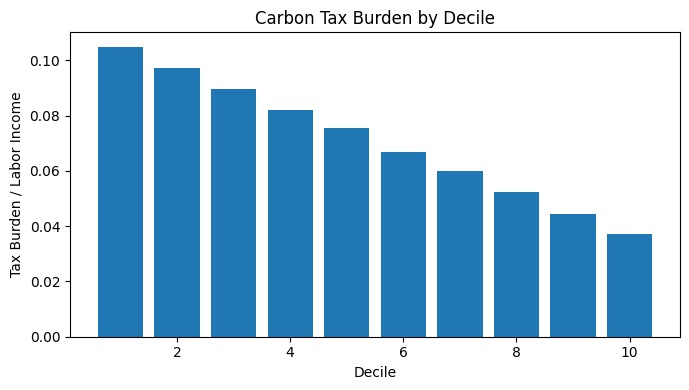

In [ ]:
burden = df_tax_only.groupby("decile").apply(
    lambda g: (tau * g["x"]).sum() /
              ((df_tax_only.attrs["w_eq"] * g["w"] * g["l"]).sum())
)

plt.figure(figsize=(7, 4))
plt.bar(burden.index + 1, burden.values)
plt.title("Carbon Tax Burden by Decile")
plt.xlabel("Decile")
plt.ylabel("Tax Burden / Labor Income")
plt.tight_layout()
plt.show()


## 8. Welfare Change by Decile

Average change in utility relative to the no-tax baseline, by income decile.


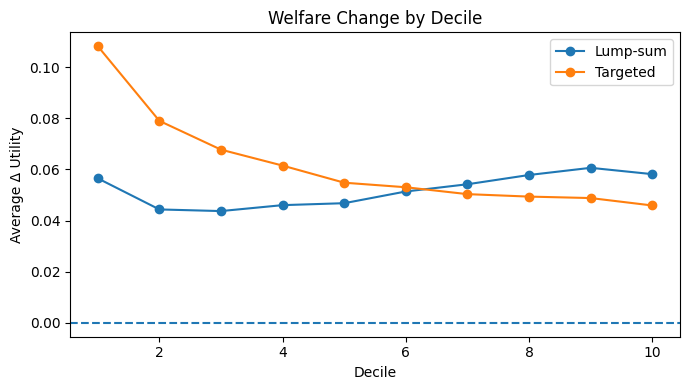

In [ ]:
welfare_lump   = df_lump.groupby("decile")["dU"].mean()
welfare_target = df_target.groupby("decile")["dU"].mean()

plt.figure(figsize=(7, 4))
plt.plot(welfare_lump.index + 1,   welfare_lump.values,   marker="o", label="Lump-sum")
plt.plot(welfare_target.index + 1, welfare_target.values, marker="o", label="Targeted")
plt.axhline(0, linestyle="--")
plt.title("Welfare Change by Decile")
plt.xlabel("Decile")
plt.ylabel("Average Δ Utility")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Change in Clean-Good Consumption

Change in `y` (the clean good) relative to the tax-only scenario,
binned into 50 income groups.

> **Note:** `dy_lump` and `dy_target` must be defined before running this cell.


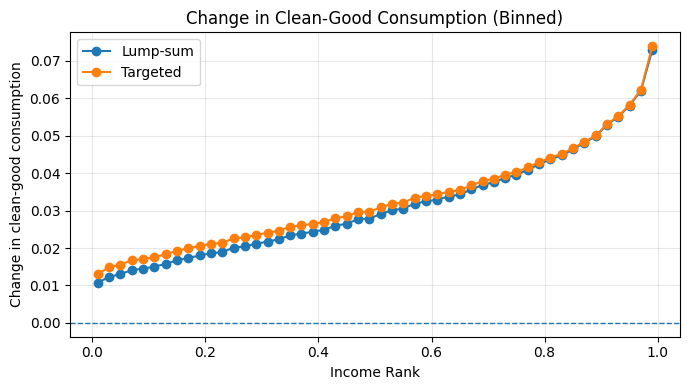

In [ ]:
dy_lump   = df_lump["y"].values   - df_tax_only["y"].values
dy_target = df_target["y"].values - df_tax_only["y"].values

bins = 50

df_plot = pd.DataFrame({
    "rank":      df_tax_only["rank"].values,
    "dy_lump":   dy_lump,
    "dy_target": dy_target
})
df_plot["bin"] = pd.qcut(df_plot["rank"], bins, labels=False)

grouped = df_plot.groupby("bin").mean()

plt.figure(figsize=(7, 4))
plt.plot(grouped["rank"], grouped["dy_lump"],   marker="o", label="Lump-sum")
plt.plot(grouped["rank"], grouped["dy_target"], marker="o", label="Targeted")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Income Rank")
plt.ylabel("Change in clean-good consumption")
plt.title("Change in Clean-Good Consumption (Binned)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Equity–Emissions Trade-off

Sweep over a grid of carbon tax rates and record total emissions and
average welfare gains for the bottom 40% of households.


Running tau = 0.00
Running tau = 0.10
Running tau = 0.20
Running tau = 0.30
Running tau = 0.40


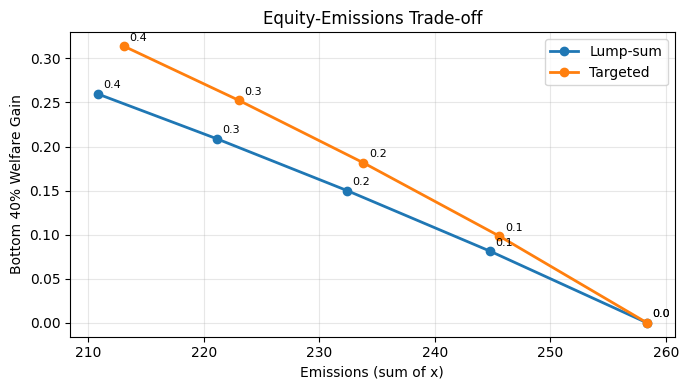

In [ ]:
tau_grid = np.array([0.00, 0.10, 0.20, 0.30, 0.40])

emissions_lump,   emissions_target = [], []
equity_lump,      equity_target    = [], []

cutoff = df0["w"].quantile(0.4)

for tau_val in tau_grid:
    print(f"Running tau = {tau_val:.2f}")

    df_tax = solve_GE(df0.copy(), "none",   tau_val)
    df_l   = solve_GE(df0.copy(), "lump",   tau_val)
    df_t   = solve_GE(df0.copy(), "target", tau_val)

    df_tax = add_utility(df_tax, tau_val)
    df_l   = add_utility(df_l,   tau_val)
    df_t   = add_utility(df_t,   tau_val)

    emissions_lump.append(df_l["x"].sum())
    emissions_target.append(df_t["x"].sum())

    bottom = df0["w"] <= cutoff
    equity_lump.append(  (df_l.loc[bottom, "U"] - df_tax.loc[bottom, "U"]).mean())
    equity_target.append((df_t.loc[bottom, "U"] - df_tax.loc[bottom, "U"]).mean())

plt.figure(figsize=(7, 4))
plt.plot(emissions_lump,   equity_lump,   marker="o", linewidth=2, label="Lump-sum")
plt.plot(emissions_target, equity_target, marker="o", linewidth=2, label="Targeted")

for i, tau_val in enumerate(tau_grid):
    plt.annotate(f"{tau_val:.1f}", (emissions_lump[i],   equity_lump[i]),
                 xytext=(4, 4), textcoords="offset points", fontsize=8)
    plt.annotate(f"{tau_val:.1f}", (emissions_target[i], equity_target[i]),
                 xytext=(4, 4), textcoords="offset points", fontsize=8)

plt.xlabel("Emissions (sum of x)")
plt.ylabel("Bottom 40% Welfare Gain")
plt.title("Equity-Emissions Trade-off")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Efficiency Cost of Recycling Schemes

Average welfare change (relative to tax-only) across a finer tau grid.


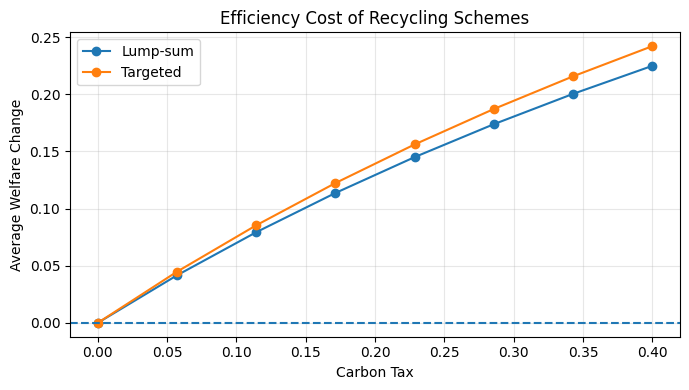

In [ ]:
tau_grid_fine = np.linspace(0.0, 0.4, 8)

eff_lump,   eff_target = [], []

for tau_val in tau_grid_fine:
    df_tax = solve_GE(df0.copy(), "none",   tau_val)
    df_l   = solve_GE(df0.copy(), "lump",   tau_val)
    df_t   = solve_GE(df0.copy(), "target", tau_val)

    df_tax = add_utility(df_tax, tau_val)
    df_l   = add_utility(df_l,   tau_val)
    df_t   = add_utility(df_t,   tau_val)

    eff_lump.append(  (df_l["U"] - df_tax["U"]).mean())
    eff_target.append((df_t["U"] - df_tax["U"]).mean())

plt.figure(figsize=(7, 4))
plt.plot(tau_grid_fine, eff_lump,   marker="o", label="Lump-sum")
plt.plot(tau_grid_fine, eff_target, marker="o", label="Targeted")
plt.axhline(0, linestyle="--")
plt.xlabel("Carbon Tax")
plt.ylabel("Average Welfare Change")
plt.title("Efficiency Cost of Recycling Schemes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Labour Market Equilibrium

Supply is flat (from the closed-form solution with T = 0).
Demand slopes down. Their intersection pins the equilibrium wage.


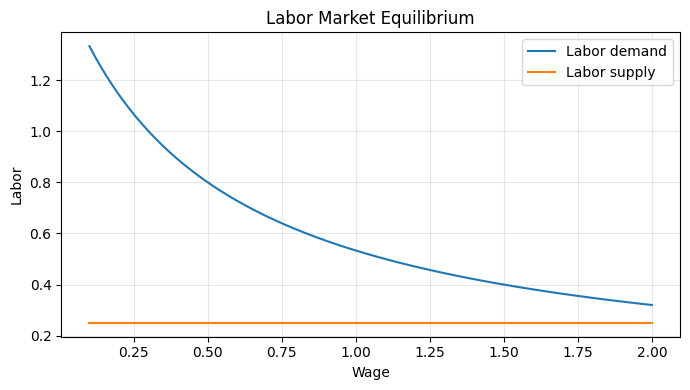

In [ ]:
w_grid = np.linspace(0.1, 2.0, 100)

L_d = 0.8 / (w_grid + 0.5)
L_s = np.ones_like(w_grid) * (1 / (1 + alpha))

plt.figure(figsize=(7, 4))
plt.plot(w_grid, L_d, label="Labor demand")
plt.plot(w_grid, L_s, label="Labor supply")
plt.xlabel("Wage")
plt.ylabel("Labor")
plt.title("Labor Market Equilibrium")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
